<a href="https://colab.research.google.com/github/yanhemis/P-S-paper/blob/heewon/%EC%8B%A4%ED%97%982_Contour_%EA%B8%B0%EB%B0%98_%EC%85%80_%EA%B2%80%EC%B6%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

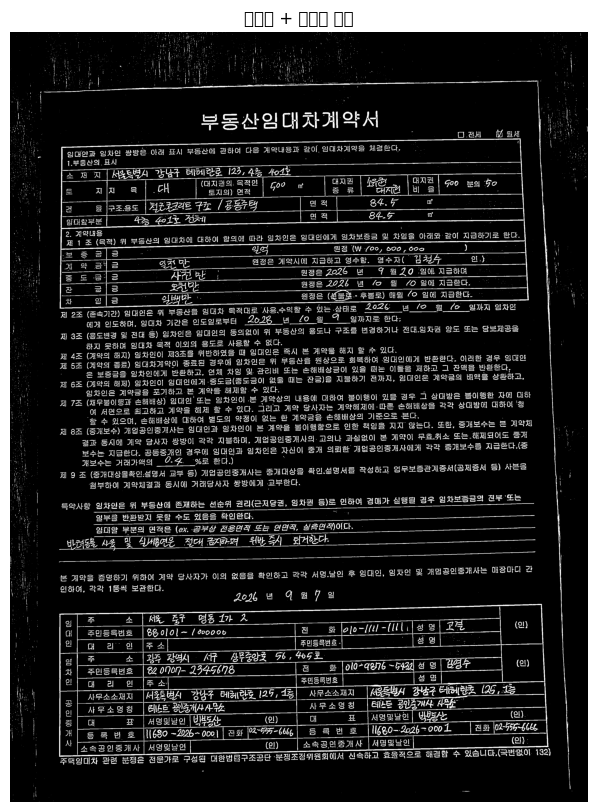

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


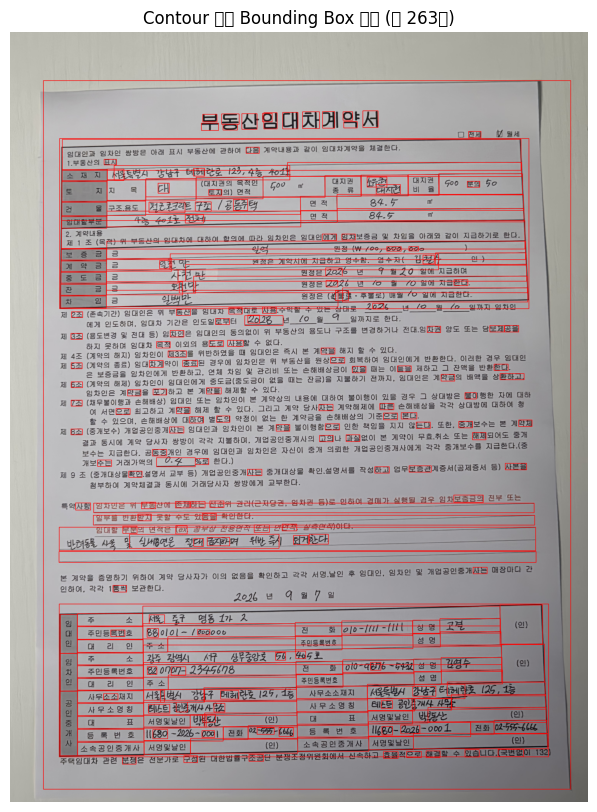

이미지 크기: 3000 x 4000
검출된 Bounding Box 개수: 263
처리 시간: 1.344초


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image

# ------------------------------------------------------------
# 0. 유틸 함수
# ------------------------------------------------------------
def show(img, title="", cmap=None):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()


def load_image(path):
    img = cv2.imread(path)

    if img is None:
        pil_img = Image.open(path).convert("RGB")
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray


# ------------------------------------------------------------
# 1. 전처리 + 이진화
# ------------------------------------------------------------
def enhance_and_binarize(gray):
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    bin_img = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        10
    )

    return bin_img


# ------------------------------------------------------------
# 2. Contour 기반 셀 검출
# ------------------------------------------------------------
def detect_cells_contour(bin_img, min_width=50, min_height=20):

    # 표선이 끊어진 부분을 조금 연결
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (5, 5)
    )

    closed = cv2.morphologyEx(
        bin_img,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Contour 검출
    contours, _ = cv2.findContours(
        closed,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        # 너무 작은 영역 제거
        if w >= min_width and h >= min_height:

            # 너무 큰 전체 영역은 제외
            if w < bin_img.shape[1] * 0.95 and \
               h < bin_img.shape[0] * 0.95:

                boxes.append((x, y, w, h))

    return boxes


# ------------------------------------------------------------
# 3. Bounding Box 그리기
# ------------------------------------------------------------
def draw_boxes(img, boxes):
    result = img.copy()

    for x, y, w, h in boxes:
        cv2.rectangle(
            result,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

    return result


# ============================================================
# 실행
# ============================================================

t0 = time.time()

# 1. 이미지 로드
img, gray = load_image("계약서.jpg")

img_h, img_w = gray.shape

# 2. 전처리
bin_img = enhance_and_binarize(gray)

# 3. Contour 기반 셀 검출
cell_boxes = detect_cells_contour(
    bin_img,
    min_width=50,
    min_height=20
)

# 4. Bounding Box 생성
result_img = draw_boxes(
    img,
    cell_boxes
)

elapsed = time.time() - t0


# ------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------

show(
    bin_img,
    title="전처리 + 이진화 결과",
    cmap="gray"
)

show(
    result_img,
    title=f"Contour 기반 Bounding Box 결과 (총 {len(cell_boxes)}개)"
)


# ------------------------------------------------------------
# 결과 출력
# ------------------------------------------------------------

print(f"이미지 크기: {img_w} x {img_h}")
print(f"검출된 Bounding Box 개수: {len(cell_boxes)}")
print(f"처리 시간: {elapsed:.3f}초")